In [13]:
# ============================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error, mean_absolute_error

from skimage.metrics import structural_similarity as ssim

In [14]:
# ============================================
# CELL 2: LOAD MNIST DATASET
# ============================================

# Load MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display original shapes
print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


In [15]:
# ============================================
# CELL 3: SELECT LABORATORY SUBSET
# ============================================

# Use 10,000 training images
x_train = x_train[:10000]
y_train = y_train[:10000]

# Use 2,000 test images
x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

Training images: (10000, 28, 28)
Test images: (2000, 28, 28)


In [16]:
# ============================================
# CELL 4: NORMALIZE PIXEL VALUES
# ============================================

# Convert integer pixel values [0, 255] to floating-point [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [17]:
# ============================================
# CELL 5: FLATTEN IMAGES
# ============================================

# Convert each 28x28 image into a 784-dimensional vector
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Training shape:", x_train_flat.shape)
print("Test shape:", x_test_flat.shape)

Training shape: (10000, 784)
Test shape: (2000, 784)


In [18]:
# ============================================
# CELL 6: BUILD FULLY CONNECTED AUTOENCODER
# ============================================

# Encoder
encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu")       # Latent representation
], name="encoder")

# Decoder
decoder = keras.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")   # Reconstructed image
], name="decoder")

# Complete autoencoder
autoencoder = keras.Sequential([
    encoder,
    decoder
], name="fully_connected_autoencoder")

# Display architecture
autoencoder.summary()

Model: "fully_connected_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 16)             │       105,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       105,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================
# CELL 7: COMPILE AUTOENCODER
# ============================================

# Adam optimizer with learning rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

In [20]:
# ============================================
# CELL 8: TRAIN AUTOENCODER
# ============================================

history = autoencoder.fit(
    x_train_flat,
    x_train_flat,              # Target is the original image itself
    validation_data=(x_test_flat, x_test_flat),
    epochs=20,
    batch_size=128,
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.3461 - val_loss: 0.2424
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2284 - val_loss: 0.2062
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1938 - val_loss: 0.1816
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1760 - val_loss: 0.1716
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1672 - val_loss: 0.1642
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1605 - val_loss: 0.1586
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1544 - val_loss: 0.1529
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1489 - val_loss: 0.1485
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1446 - val_loss: 0.1451
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1417 - val_loss: 0.1428
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1396 - val_loss: 0.1408
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1377 - val_l

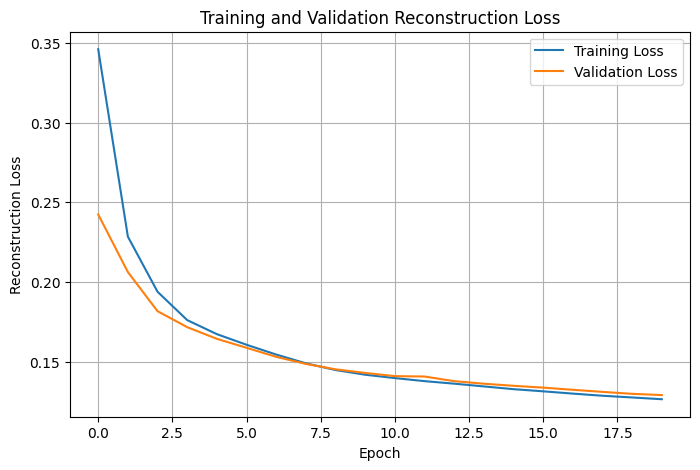

In [21]:
# ============================================
# CELL 9: TRAINING vs VALIDATION LOSS
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Training and Validation Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
# ============================================
# CELL 10: RECONSTRUCT TEST IMAGES
# ============================================

# Generate reconstructed images
x_test_reconstructed = autoencoder.predict(x_test_flat)

print("Reconstructed shape:", x_test_reconstructed.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Reconstructed shape: (2000, 784)


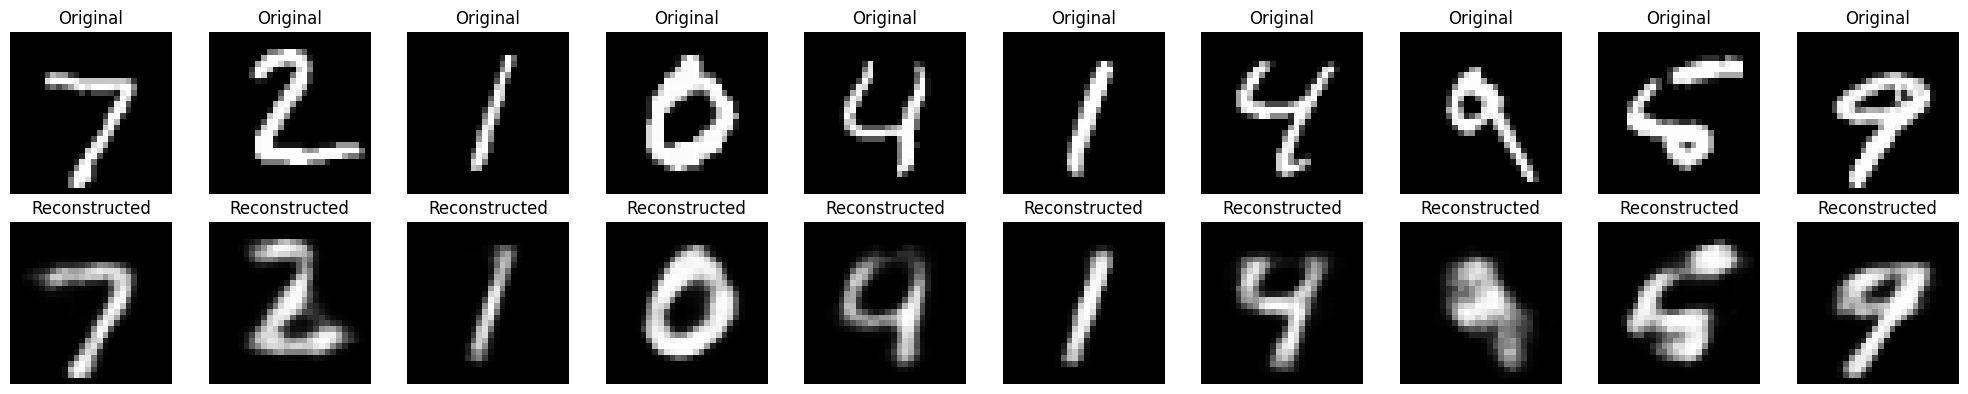

In [23]:
# ============================================
# CELL 11: ORIGINAL vs RECONSTRUCTED IMAGES
# ============================================

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# ============================================
# CELL 12: CALCULATE MSE AND MAE
# ============================================

# Mean Squared Error
mse = np.mean((x_test_flat - x_test_reconstructed) ** 2)

# Mean Absolute Error
mae = np.mean(np.abs(x_test_flat - x_test_reconstructed))

print("Test MSE:", mse)
print("Test MAE:", mae)

Test MSE: 0.022667764
Test MAE: 0.059465293


In [25]:
# ============================================
# CELL 13: CALCULATE MEAN SSIM
# ============================================

ssim_values = []

for i in range(len(x_test)):

    # Reshape flattened vectors back to 28x28 images
    original = x_test[i]
    reconstructed = x_test_reconstructed[i].reshape(28, 28)

    # Calculate SSIM for this image
    score = ssim(
        original,
        reconstructed,
        data_range=1.0
    )

    ssim_values.append(score)

# Average SSIM over the complete test set
mean_ssim = np.mean(ssim_values)

print("Mean SSIM:", mean_ssim)

Mean SSIM: 0.7287425969371615


In [26]:
# ============================================
# CELL 14: BASIC AUTOENCODER RESULTS
# ============================================

print("===================================")
print("FULLY CONNECTED AUTOENCODER RESULTS")
print("===================================")
print(f"Test MSE   : {mse:.6f}")
print(f"Test MAE   : {mae:.6f}")
print(f"Mean SSIM  : {mean_ssim:.6f}")

FULLY CONNECTED AUTOENCODER RESULTS
Test MSE   : 0.022668
Test MAE   : 0.059465
Mean SSIM  : 0.728743


In [27]:
# ============================================
# CELL 15: PREPARE IMAGES FOR CONVOLUTIONAL AE
# ============================================

# Add the channel dimension required by Conv2D
# Shape changes:
# (10000, 28, 28) -> (10000, 28, 28, 1)

x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train_cnn.shape)
print("Test shape:", x_test_cnn.shape)

Training shape: (10000, 28, 28, 1)
Test shape: (2000, 28, 28, 1)


In [28]:
# ============================================
# CELL 16: BUILD CONVOLUTIONAL AUTOENCODER
# ============================================

conv_autoencoder = keras.Sequential([

    # ---------------- ENCODER ----------------

    # Input: 28 x 28 x 1
    layers.Input(shape=(28, 28, 1)),

    # Extract 32 feature maps
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Reduce spatial dimensions:
    # 28 x 28 -> 14 x 14
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    # Extract 64 feature maps
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Reduce spatial dimensions:
    # 14 x 14 -> 7 x 7
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    # Latent feature representation
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # ---------------- DECODER ----------------

    # 7 x 7 -> 14 x 14
    layers.UpSampling2D((2, 2)),

    # Reduce feature maps from 64 -> 32
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # 14 x 14 -> 28 x 28
    layers.UpSampling2D((2, 2)),

    # Reconstruct the original single-channel image
    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
], name="convolutional_autoencoder")

conv_autoencoder.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ============================================
# CELL 17: COMPILE CONVOLUTIONAL AUTOENCODER
# ============================================

conv_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

In [30]:
# ============================================
# CELL 18: TRAIN CONVOLUTIONAL AUTOENCODER
# ============================================

conv_history = conv_autoencoder.fit(
    x_train_cnn,
    x_train_cnn,                         # Target = original image
    validation_data=(x_test_cnn, x_test_cnn),
    epochs=20,
    batch_size=128,
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.2228 - val_loss: 0.1004
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0903 - val_loss: 0.0825
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0818 - val_loss: 0.0789
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0781 - val_loss: 0.0751
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0761 - val_loss: 0.0736
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0744 - val_loss: 0.0726
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0734 - val_loss: 0.0716
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0726 - val_loss: 0.0707
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0718 - val_loss: 0.0707
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0714 - val_loss: 0.0698
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0708 - val_loss: 0.0691
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0705 - va

In [31]:
# ============================================
# CELL 19: CAE RECONSTRUCTIONS
# ============================================

x_test_cae_reconstructed = conv_autoencoder.predict(
    x_test_cnn
)

print(
    "Reconstructed shape:",
    x_test_cae_reconstructed.shape
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Reconstructed shape: (2000, 28, 28, 1)


In [32]:
# ============================================
# CELL 20: CAE RECONSTRUCTION METRICS
# ============================================

# MSE
cae_mse = np.mean(
    (x_test_cnn - x_test_cae_reconstructed) ** 2
)

# MAE
cae_mae = np.mean(
    np.abs(x_test_cnn - x_test_cae_reconstructed)
)

# SSIM for every test image
cae_ssim_values = []

for i in range(len(x_test_cnn)):

    original = x_test_cnn[i].squeeze()
    reconstructed = x_test_cae_reconstructed[i].squeeze()

    score = ssim(
        original,
        reconstructed,
        data_range=1.0
    )

    cae_ssim_values.append(score)

cae_mean_ssim = np.mean(cae_ssim_values)

print(f"CAE Test MSE  : {cae_mse:.6f}")
print(f"CAE Test MAE  : {cae_mae:.6f}")
print(f"CAE Mean SSIM : {cae_mean_ssim:.6f}")

CAE Test MSE  : 0.002580
CAE Test MAE  : 0.014898
CAE Mean SSIM : 0.974509


In [33]:
# ============================================
# CELL 21: FC-AE vs CAE COMPARISON
# ============================================

fc_parameters = autoencoder.count_params()
cae_parameters = conv_autoencoder.count_params()

print("==============================================")
print("MODEL COMPARISON")
print("==============================================")

print(f"{'Model':<25} {'MSE':<12} {'MAE':<12} {'SSIM':<12} {'Parameters'}")
print("-" * 75)

print(
    f"{'Fully Connected AE':<25} "
    f"{mse:<12.6f} "
    f"{mae:<12.6f} "
    f"{mean_ssim:<12.6f} "
    f"{fc_parameters}"
)

print(
    f"{'Convolutional AE':<25} "
    f"{cae_mse:<12.6f} "
    f"{cae_mae:<12.6f} "
    f"{cae_mean_ssim:<12.6f} "
    f"{cae_parameters}"
)

MODEL COMPARISON
Model                     MSE          MAE          SSIM         Parameters
---------------------------------------------------------------------------
Fully Connected AE        0.022668     0.059465     0.728743     211040
Convolutional AE          0.002580     0.014898     0.974509     74497


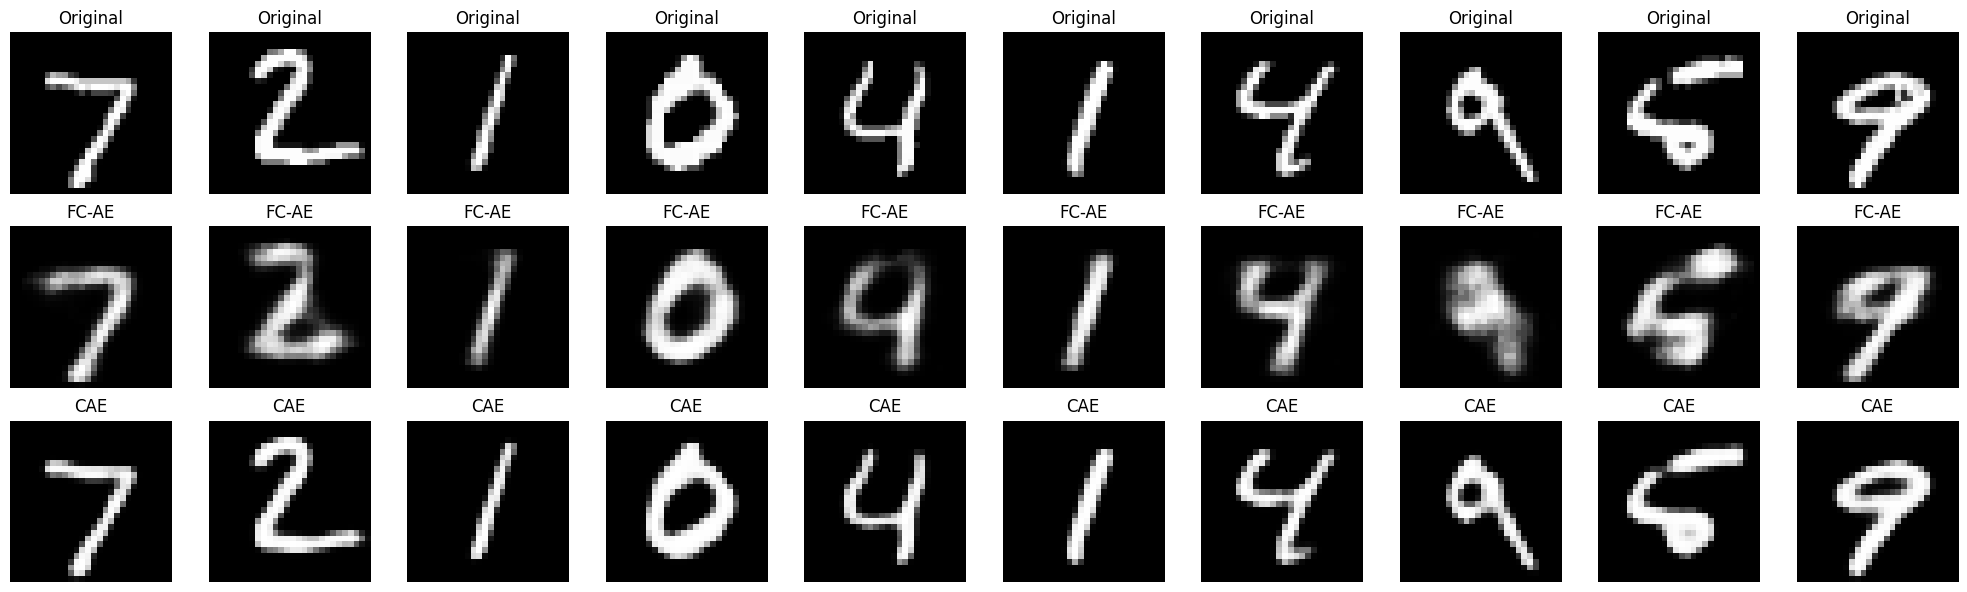

In [34]:
# ============================================
# CELL 22: RECONSTRUCTION COMPARISON
# ORIGINAL vs FC-AE vs CAE
# ============================================

n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    # ---------------- ORIGINAL ----------------
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # ---------------- FC-AE ----------------
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(
        x_test_reconstructed[i].reshape(28, 28),
        cmap="gray"
    )
    plt.title("FC-AE")
    plt.axis("off")

    # ---------------- CAE ----------------
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(
        x_test_cae_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.title("CAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# ============================================
# CELL 23: GAUSSIAN NOISE FUNCTION
# ============================================

def add_gaussian_noise(images, sigma):
    """
    Add Gaussian noise to images.

    sigma = standard deviation of Gaussian noise
    """

    # Generate Gaussian noise
    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    # Add noise to the original image
    noisy_images = images + noise

    # Keep pixel values within [0, 1]
    noisy_images = np.clip(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images.astype("float32")

In [36]:
# ============================================
# CELL 24: SALT-AND-PEPPER NOISE FUNCTION
# ============================================

def add_salt_pepper_noise(images, p):
    """
    Add salt-and-pepper noise.

    p = proportion of pixels to corrupt.
    """

    # Make a copy so the original images are unchanged
    noisy_images = images.copy()

    # Generate random values for every pixel
    random_values = np.random.random(images.shape)

    # Pixels below p/2 become black (0)
    noisy_images[random_values < p / 2] = 0.0

    # Pixels above 1 - p/2 become white (1)
    noisy_images[random_values > 1 - p / 2] = 1.0

    return noisy_images.astype("float32")

In [37]:
# ============================================
# CELL 25: CREATE NOISY TRAINING DATA
# ============================================

# Use Gaussian noise with sigma = 0.2
train_noisy = add_gaussian_noise(
    x_train_cnn,
    sigma=0.2
)

print("Clean images :", x_train_cnn.shape)
print("Noisy images :", train_noisy.shape)

Clean images : (10000, 28, 28, 1)
Noisy images : (10000, 28, 28, 1)


In [38]:
# ============================================
# CELL 26: BUILD DENOISING CONVOLUTIONAL AE
# ============================================

denoising_cae = keras.models.clone_model(
    conv_autoencoder
)

denoising_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

denoising_cae.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ============================================
# CELL 27: TRAIN DENOISING AUTOENCODER
# ============================================

denoising_history = denoising_cae.fit(
    train_noisy,                       # Noisy input
    x_train_cnn,                       # Clean target
    validation_data=(
        add_gaussian_noise(x_test_cnn, sigma=0.2),
        x_test_cnn
    ),
    epochs=20,
    batch_size=128,
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2676 - val_loss: 0.1196
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1046 - val_loss: 0.0967
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0921 - val_loss: 0.0877
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0869 - val_loss: 0.0842
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0838 - val_loss: 0.0820
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0818 - val_loss: 0.0797
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0804 - val_loss: 0.0788
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0794 - val_loss: 0.0781
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0785 - val_loss: 0.0783
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0780 - val_loss: 0.0768
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0775 - val_loss: 0.0759
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0769 - val_l

In [40]:
# ============================================
# CELL 28: CREATE NOISY TEST IMAGES
# ============================================

# Gaussian noise with sigma = 0.2
test_noisy = add_gaussian_noise(
    x_test_cnn,
    sigma=0.2
)

# Denoise the noisy images
test_denoised = denoising_cae.predict(
    test_noisy
)

print("Denoised shape:", test_denoised.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Denoised shape: (2000, 28, 28, 1)


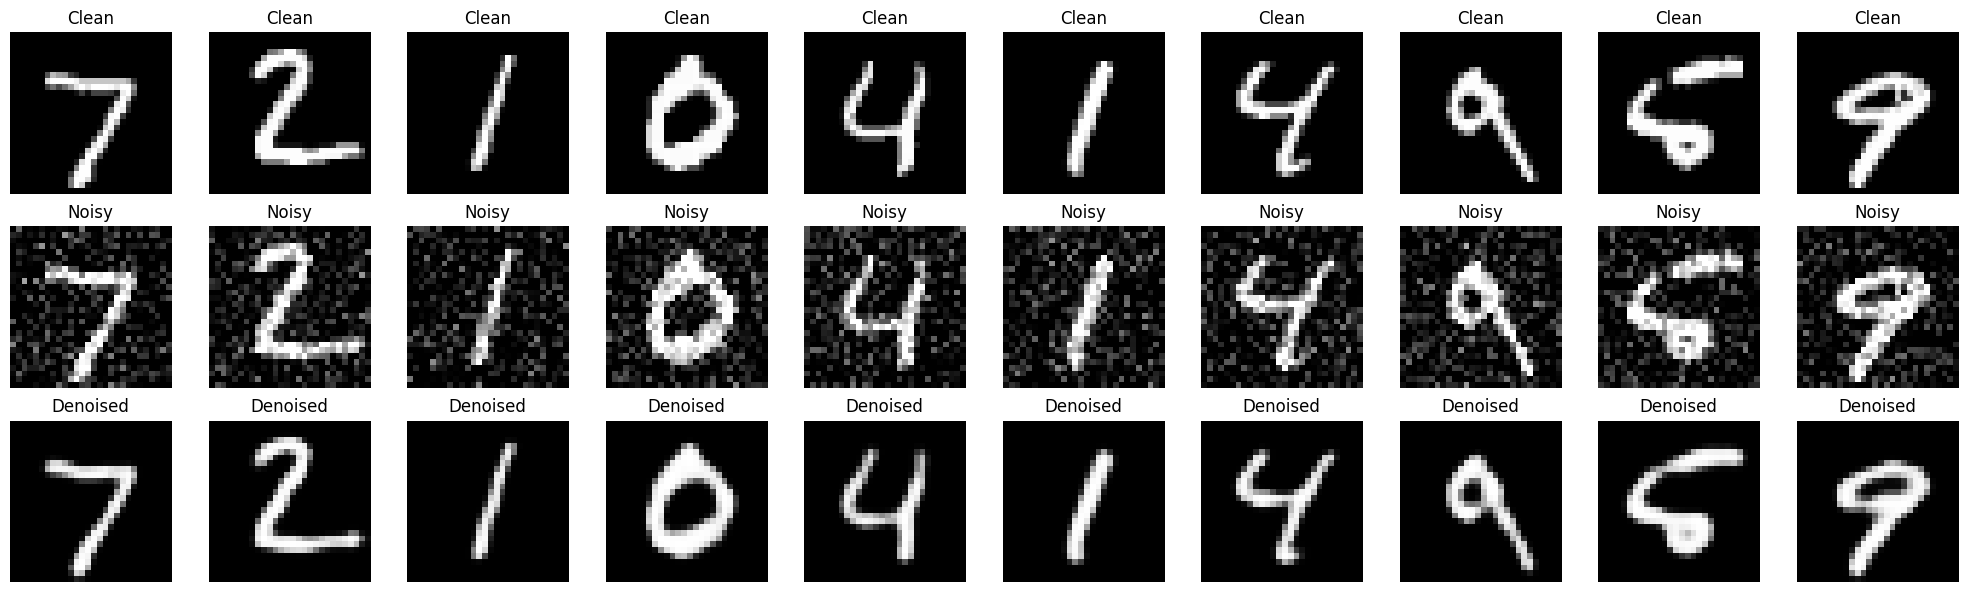

In [41]:
# ============================================
# CELL 29: CLEAN vs NOISY vs DENOISED
# ============================================

n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    # Clean image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_cnn[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Noisy image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(test_denoised[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
# ============================================
# CELL 30: RECONSTRUCTION METRICS FUNCTION
# ============================================

def calculate_metrics(original_images, reconstructed_images):

    # MSE
    mse_value = np.mean(
        (original_images - reconstructed_images) ** 2
    )

    # MAE
    mae_value = np.mean(
        np.abs(original_images - reconstructed_images)
    )

    # SSIM
    ssim_values = []

    for i in range(len(original_images)):

        original = original_images[i].squeeze()
        reconstructed = reconstructed_images[i].squeeze()

        score = ssim(
            original,
            reconstructed,
            data_range=1.0
        )

        ssim_values.append(score)

    mean_ssim_value = np.mean(ssim_values)

    return mse_value, mae_value, mean_ssim_value

In [43]:
# ============================================
# CELL 31: EVALUATE DIFFERENT GAUSSIAN NOISE LEVELS
# ============================================

noise_levels = [0.1, 0.2, 0.3]

gaussian_results = []

for sigma in noise_levels:

    # Add Gaussian noise to test images
    noisy_images = add_gaussian_noise(
        x_test_cnn,
        sigma=sigma
    )

    # Reconstruct / denoise
    denoised_images = denoising_cae.predict(
        noisy_images,
        verbose=0
    )

    # Calculate metrics against CLEAN images
    mse_value, mae_value, ssim_value = calculate_metrics(
        x_test_cnn,
        denoised_images
    )

    gaussian_results.append(
        [sigma, mse_value, mae_value, ssim_value]
    )

# Display results
print("Noise Level    MSE         MAE         SSIM")
print("-" * 50)

for result in gaussian_results:
    print(
        f"{result[0]:<13} "
        f"{result[1]:.6f}   "
        f"{result[2]:.6f}   "
        f"{result[3]:.6f}"
    )

Noise Level    MSE         MAE         SSIM
--------------------------------------------------
0.1           0.003409   0.017357   0.960372
0.2           0.004472   0.020807   0.946717
0.3           0.007147   0.028827   0.884323


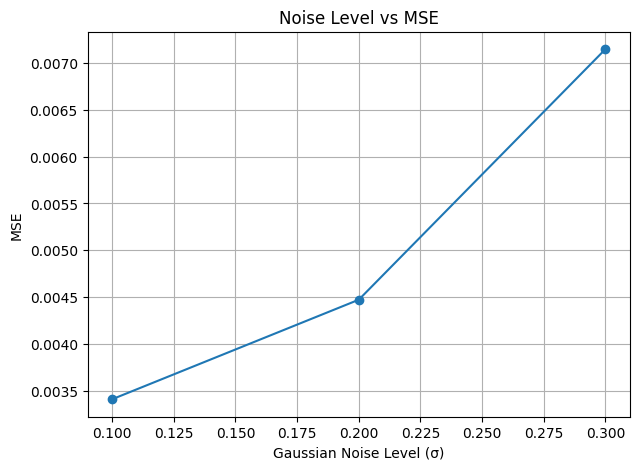

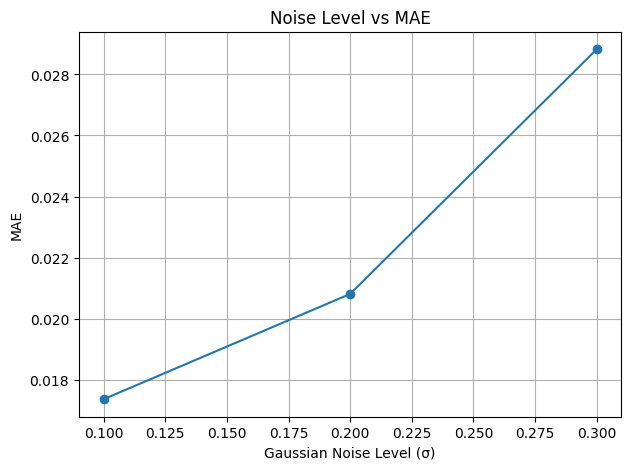

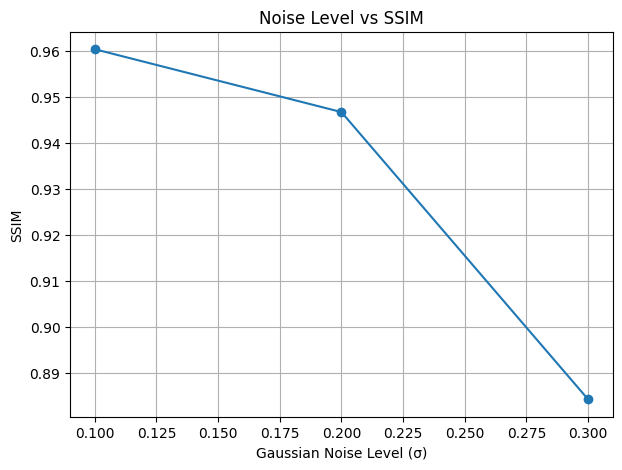

In [44]:
# ============================================
# CELL 32: NOISE LEVEL vs RECONSTRUCTION QUALITY
# ============================================

mse_values = [r[1] for r in gaussian_results]
mae_values = [r[2] for r in gaussian_results]
ssim_values = [r[3] for r in gaussian_results]

# -------- MSE --------
plt.figure(figsize=(7, 5))
plt.plot(noise_levels, mse_values, marker="o")
plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MSE")
plt.title("Noise Level vs MSE")
plt.grid(True)
plt.show()

# -------- MAE --------
plt.figure(figsize=(7, 5))
plt.plot(noise_levels, mae_values, marker="o")
plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MAE")
plt.title("Noise Level vs MAE")
plt.grid(True)
plt.show()

# -------- SSIM --------
plt.figure(figsize=(7, 5))
plt.plot(noise_levels, ssim_values, marker="o")
plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("SSIM")
plt.title("Noise Level vs SSIM")
plt.grid(True)
plt.show()

In [45]:
# ============================================
# CELL 33: SALT-AND-PEPPER NOISE EVALUATION
# ============================================

sp_levels = [0.05, 0.10, 0.20]

sp_results = []

for p in sp_levels:

    # Add salt-and-pepper noise
    noisy_images = add_salt_pepper_noise(
        x_test_cnn,
        p=p
    )

    # Denoise
    denoised_images = denoising_cae.predict(
        noisy_images,
        verbose=0
    )

    # Compare against clean images
    mse_value, mae_value, ssim_value = calculate_metrics(
        x_test_cnn,
        denoised_images
    )

    sp_results.append(
        [p, mse_value, mae_value, ssim_value]
    )

print("Corruption    MSE         MAE         SSIM")
print("-" * 50)

for result in sp_results:
    print(
        f"{result[0]:<13.2f} "
        f"{result[1]:.6f}   "
        f"{result[2]:.6f}   "
        f"{result[3]:.6f}"
    )

Corruption    MSE         MAE         SSIM
--------------------------------------------------
0.05          0.004848   0.021361   0.928545
0.10          0.007533   0.028325   0.870612
0.20          0.015393   0.046202   0.721444


In [46]:
latent_dim = 2

def calculate_metrics(original_images, reconstructed_images):

    # MSE
    mse_value = np.mean(
        (original_images - reconstructed_images) ** 2
    )

    # MAE
    mae_value = np.mean(
        np.abs(original_images - reconstructed_images)
    )

    # SSIM
    ssim_values = []

    for i in range(len(original_images)):

        original = original_images[i].squeeze()
        reconstructed = reconstructed_images[i].squeeze()

        score = ssim(
            original,
            reconstructed,
            data_range=1.0
        )

        ssim_values.append(score)

    mean_ssim_value = np.mean(ssim_values)

    return mse_value, mae_value, mean_ssim_value


def sample_latent(args):
    """
    Reparameterization trick:

    z = μ + σ * ε

    where ε ~ N(0, I)
    """

    mu, log_var = args

    # Convert log variance to standard deviation
    sigma = tf.exp(0.5 * log_var)

    # Sample epsilon from standard normal distribution
    epsilon = tf.random.normal(
        shape=tf.shape(mu)
    )

    # Reparameterization
    z = mu + sigma * epsilon

    return z

# VAE Implementation

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class VAE(tf.keras.Model):
    def __init__(self, latent_dim=2, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.Input(shape=(28, 28, 1)),
                tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
                tf.keras.layers.MaxPooling2D((2, 2), padding="same"),
                tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
                tf.keras.layers.MaxPooling2D((2, 2), padding="same"),
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(128, activation="relu"),
                tf.keras.layers.Dense(latent_dim + latent_dim, name="latent_vectors"), # For mu and log_var
            ],
            name="encoder",
        )

        # Decoder
        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.Input(shape=(latent_dim,)),
                tf.keras.layers.Dense(7 * 7 * 64, activation="relu"),
                tf.keras.layers.Reshape((7, 7, 64)),
                tf.keras.layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same"),
                tf.keras.layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same"),
                tf.keras.layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same"),
            ],
            name="decoder",
        )

        # Metrics for tracking
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @tf.function
    def sample_latent(self, mu, log_var):
        sigma = tf.exp(0.5 * log_var)
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + sigma * epsilon

    def call(self, inputs):
        mu_log_var = self.encoder(inputs)
        mu = mu_log_var[:, :self.latent_dim]
        log_var = mu_log_var[:, self.latent_dim:]
        z = self.sample_latent(mu, log_var)
        reconstruction = self.decoder(z)
        return reconstruction, mu, log_var, z

    def compile(self, optimizer, **kwargs):
        super().compile(**kwargs)
        self.optimizer = optimizer

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            reconstruction, mu, log_var, z = self(x)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(x, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var - tf.square(mu) - tf.exp(log_var),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        reconstruction, mu, log_var, z = self(x)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(x, reconstruction),
                axis=(1, 2),
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


# VAE Training

In [48]:
vae = VAE(latent_dim=2)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

# Train the VAE
vae_history = vae.fit(
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn,),
    shuffle=True
)


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - kl_loss: 2.7521 - loss: 301.9452 - reconstruction_loss: 299.1931 - val_kl_loss: 3.2081 - val_loss: 202.4800 - val_reconstruction_loss: 199.2719
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.4104 - loss: 204.3648 - reconstruction_loss: 200.9544 - val_kl_loss: 3.4766 - val_loss: 192.9139 - val_reconstruction_loss: 189.4373
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.0968 - loss: 196.6835 - reconstruction_loss: 193.5867 - val_kl_loss: 2.9090 - val_loss: 188.1742 - val_reconstruction_loss: 185.2653
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 2.6068 - loss: 193.0173 - reconstruction_loss: 190.4105 - val_kl_loss: 2.5080 - val_loss: 185.3926 - val_reconstruction_loss: 182.8846
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 2.4934 - loss: 190.9188 - reconstruction_loss: 188.4255 - val_kl_loss: 2.5318 - val_loss: 183.5035 - val_reconstruction_loss: 180.9717
Epoch 6/20
79/7

In [49]:
# ============================================
# CELL 40: EXTRACT VAE LATENT REPRESENTATIONS
# ============================================

# Get reconstruction, μ, log variance and sampled z
_, test_mu, test_log_var, test_z = vae.predict(
    x_test_cnn,
    verbose=0
)

print("Latent representation shape:", test_z.shape)

Latent representation shape: (2000, 2)


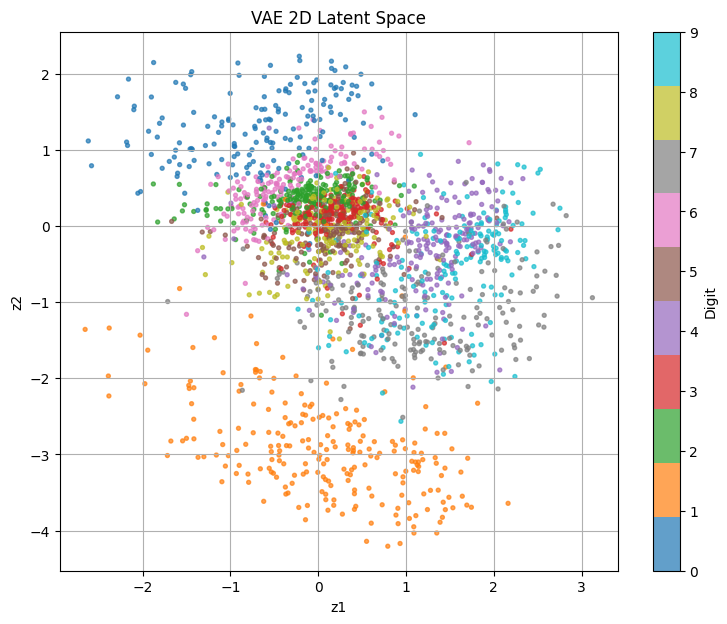

In [50]:
# ============================================
# CELL 41: VAE LATENT SPACE VISUALIZATION
# ============================================

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    test_z[:, 0],
    test_z[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE 2D Latent Space")

plt.colorbar(
    scatter,
    label="Digit"
)

plt.grid(True)
plt.show()

In [51]:
# ============================================
# CELL 42: GENERATE NEW VAE IMAGES
# ============================================

num_generated = 25

# Sample random points from N(0, I)
random_latent_vectors = np.random.normal(
    size=(num_generated, vae.latent_dim)
).astype("float32")

# Generate images using the decoder
generated_images = vae.decoder.predict(
    random_latent_vectors,
    verbose=0
)

print("Generated images:", generated_images.shape)


Generated images: (25, 28, 28, 1)


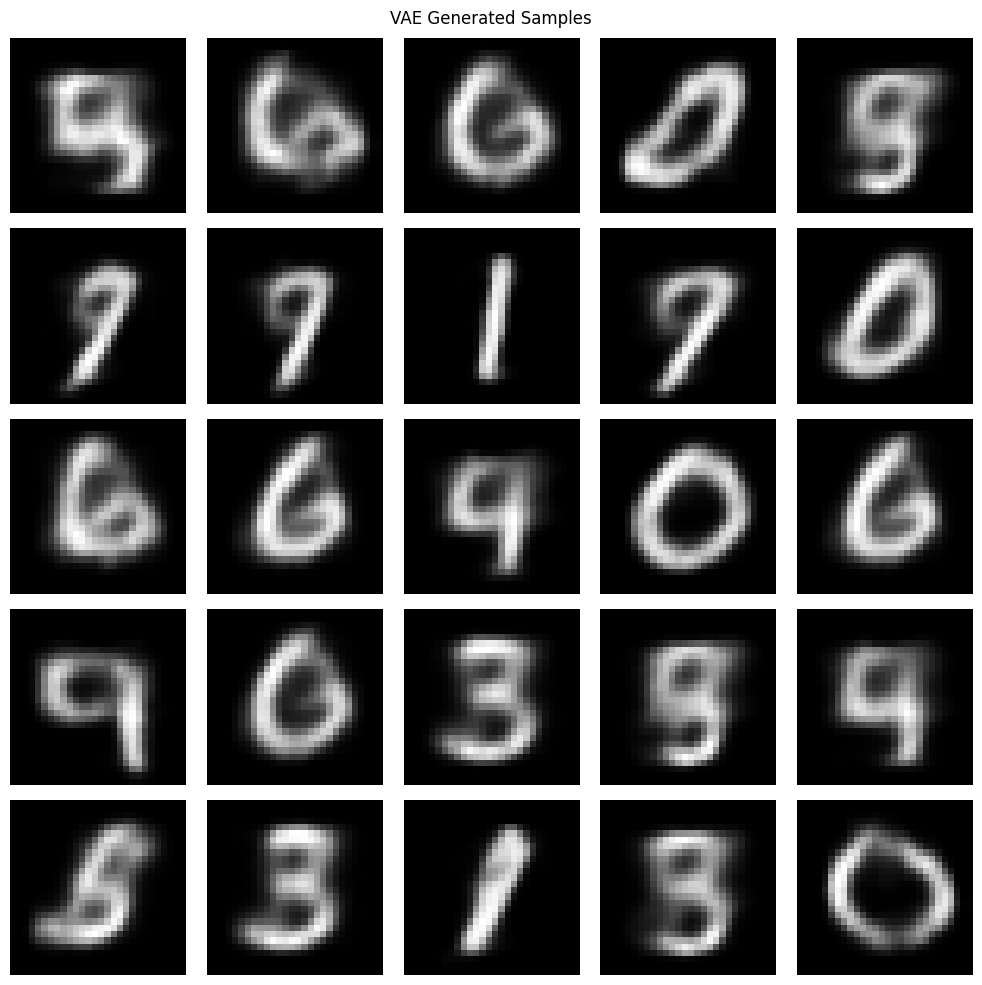

In [52]:
# ============================================
# CELL 43: RANDOMLY GENERATED VAE IMAGES
# ============================================

plt.figure(figsize=(10, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("VAE Generated Samples")
plt.tight_layout()
plt.show()

In [53]:
# ============================================
# CELL 44: SELECT TWO LATENT VECTORS
# ============================================

# Select two latent vectors from the test set
z_A = test_z[0]
z_B = test_z[1]

# Values of alpha from 0 to 1
alphas = np.arange(
    0.0,
    1.01,
    0.1
)

print("z_A:", z_A)
print("z_B:", z_B)
print("Alpha values:", alphas)

z_A: [ 0.88888115 -1.0504183 ]
z_B: [-0.32011524  0.58149457]
Alpha values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [54]:
# ============================================
# CELL 45: LATENT SPACE INTERPOLATION
# ============================================

interpolated_z = []

for alpha in alphas:

    # z(alpha) = (1-alpha)zA + alpha*zB
    z_interpolated = (
        (1 - alpha) * z_A
        + alpha * z_B
    )

    interpolated_z.append(
        z_interpolated
    )

interpolated_z = np.array(
    interpolated_z
).astype("float32")

print(
    "Interpolated latent shape:",
    interpolated_z.shape
)

Interpolated latent shape: (11, 2)


In [55]:
# ============================================
# CELL 46: DECODE INTERPOLATED VECTORS
# ============================================

interpolated_images = vae.decoder.predict(
    interpolated_z,
    verbose=0
)

print(
    "Interpolated images:",
    interpolated_images.shape
)

Interpolated images: (11, 28, 28, 1)


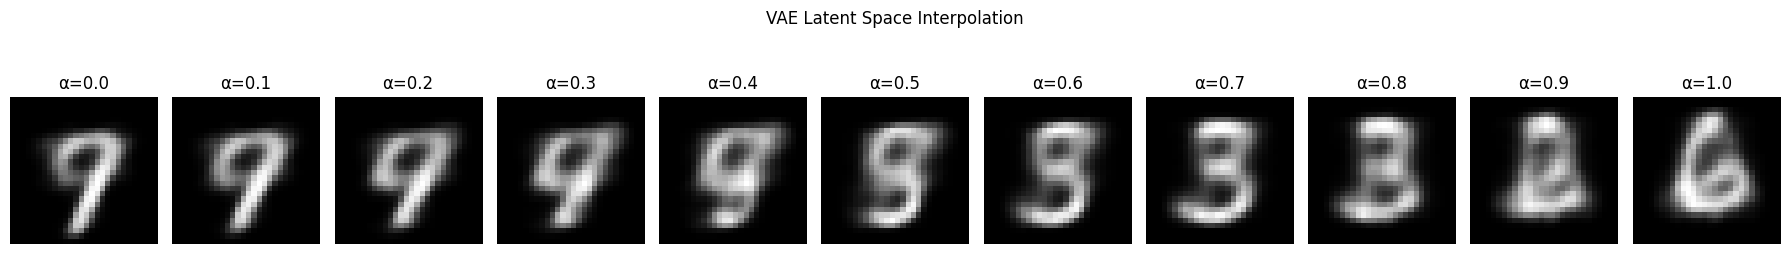

In [56]:
# ============================================
# CELL 47: LATENT SPACE INTERPOLATION PLOT
# ============================================

plt.figure(figsize=(18, 3))

for i in range(len(interpolated_images)):

    plt.subplot(1, len(interpolated_images), i + 1)

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"α={alphas[i]:.1f}")
    plt.axis("off")

plt.suptitle("VAE Latent Space Interpolation")
plt.tight_layout()
plt.show()

In [57]:
# ============================================
# CELL 48: DENOISING CAE METRICS
# ============================================

denoise_mse, denoise_mae, denoise_ssim = calculate_metrics(
    x_test_cnn,
    test_denoised
)

print(f"Denoising CAE MSE  : {denoise_mse:.6f}")
print(f"Denoising CAE MAE  : {denoise_mae:.6f}")
print(f"Denoising CAE SSIM : {denoise_ssim:.6f}")

Denoising CAE MSE  : 0.004471
Denoising CAE MAE  : 0.020788
Denoising CAE SSIM : 0.946785


In [58]:
# ============================================
# CELL 49: VAE RECONSTRUCTION METRICS
# ============================================

# Reconstruct test images through the VAE
vae_reconstructed, _, _, _ = vae.predict(
    x_test_cnn,
    verbose=0
)

# Calculate MSE, MAE and SSIM
vae_mse, vae_mae, vae_ssim = calculate_metrics(
    x_test_cnn,
    vae_reconstructed
)

print(f"VAE Test MSE  : {vae_mse:.6f}")
print(f"VAE Test MAE  : {vae_mae:.6f}")
print(f"VAE Mean SSIM : {vae_ssim:.6f}")

VAE Test MSE  : 0.044742
VAE Test MAE  : 0.103395
VAE Mean SSIM : 0.467958


In [59]:
# ============================================
# CELL 50: VAE LOSS VALUES
# ============================================

# Final training losses
vae_total_loss = vae_history.history["loss"][-1]

vae_reconstruction_loss = (
    vae_history.history["reconstruction_loss"][-1]
)

vae_kl_loss = (
    vae_history.history["kl_loss"][-1]
)

print("===================================")
print("VAE LOSS RESULTS")
print("===================================")

print(
    f"Reconstruction Loss : "
    f"{vae_reconstruction_loss:.6f}"
)

print(
    f"KL Loss             : "
    f"{vae_kl_loss:.6f}"
)

print(
    f"Total Loss          : "
    f"{vae_total_loss:.6f}"
)

VAE LOSS RESULTS
Reconstruction Loss : 150.143799
KL Loss             : 5.617647
Total Loss          : 155.761490


In [60]:
# ============================================
# CELL 51: FINAL RECONSTRUCTION COMPARISON
# ============================================

print("==============================================================")
print("RECONSTRUCTION COMPARISON")
print("==============================================================")

print(
    f"{'Model':<25}"
    f"{'MSE':<12}"
    f"{'MAE':<12}"
    f"{'SSIM':<12}"
    f"{'Parameters'}"
)

print("-" * 75)

print(
    f"{'Fully Connected AE':<25}"
    f"{mse:<12.6f}"
    f"{mae:<12.6f}"
    f"{mean_ssim:<12.6f}"
    f"{fc_parameters}"
)

print(
    f"{'Convolutional AE':<25}"
    f"{cae_mse:<12.6f}"
    f"{cae_mae:<12.6f}"
    f"{cae_mean_ssim:<12.6f}"
    f"{cae_parameters}"
)

print(
    f"{'Denoising CAE':<25}"
    f"{denoise_mse:<12.6f}"
    f"{denoise_mae:<12.6f}"
    f"{denoise_ssim:<12.6f}"
    f"{denoising_cae.count_params()}"
)

print(
    f"{'VAE':<25}"
    f"{vae_mse:<12.6f}"
    f"{vae_mae:<12.6f}"
    f"{vae_ssim:<12.6f}"
    f"{vae.count_params()}"
)

print("\nVAE Losses:")
print(f"Reconstruction Loss : {vae_reconstruction_loss:.6f}")
print(f"KL Loss             : {vae_kl_loss:.6f}")
print(f"Total Loss          : {vae_total_loss:.6f}")

RECONSTRUCTION COMPARISON
Model                    MSE         MAE         SSIM        Parameters
---------------------------------------------------------------------------
Fully Connected AE       0.022668    0.059465    0.728743    211040
Convolutional AE         0.002580    0.014898    0.974509    74497
Denoising CAE            0.004471    0.020788    0.946785    74497
VAE                      0.044742    0.103395    0.467958    485957

VAE Losses:
Reconstruction Loss : 150.143799
KL Loss             : 5.617647
Total Loss          : 155.761490


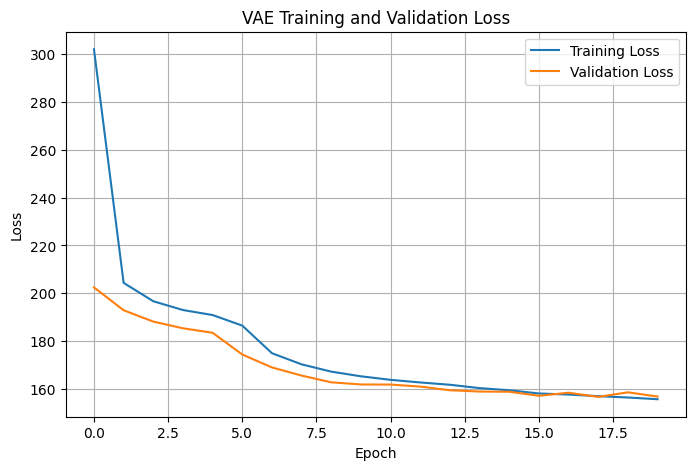

In [61]:
# ============================================
# CELL 52: VAE TRAINING / VALIDATION LOSS
# ============================================

plt.figure(figsize=(8, 5))

# Training total loss
plt.plot(
    vae_history.history["loss"],
    label="Training Loss"
)

# Validation total loss
if "val_loss" in vae_history.history:
    plt.plot(
        vae_history.history["val_loss"],
        label="Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [62]:
# ============================================
# CELL 53: PER-IMAGE RECONSTRUCTION ERROR
# ============================================

# Calculate MSE separately for every test image
per_image_errors = np.mean(
    (x_test_cnn - x_test_cae_reconstructed) ** 2,
    axis=(1, 2, 3)
)

print("Number of reconstruction errors:", len(per_image_errors))
print("Minimum error:", per_image_errors.min())
print("Maximum error:", per_image_errors.max())
print("Mean error:", per_image_errors.mean())

Number of reconstruction errors: 2000
Minimum error: 0.00030194165
Maximum error: 0.009358028
Mean error: 0.0025799528


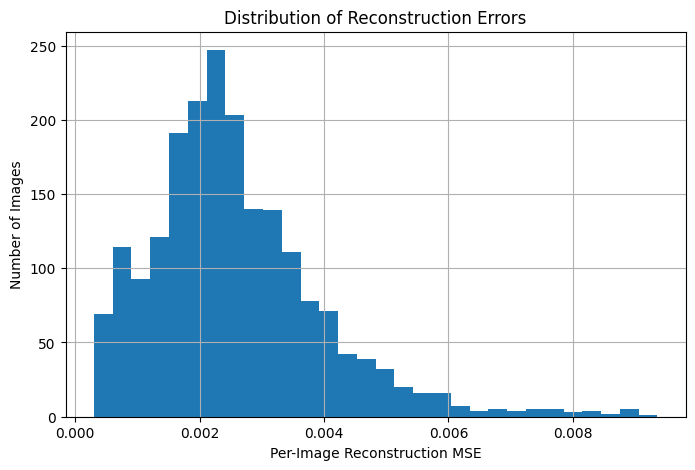

In [63]:
# ============================================
# CELL 54: RECONSTRUCTION ERROR DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

plt.hist(
    per_image_errors,
    bins=30
)

plt.xlabel("Per-Image Reconstruction MSE")
plt.ylabel("Number of Images")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True)

plt.show()

In [64]:
# ============================================
# CELL 55: TOP 5 HIGH-ERROR IMAGES
# ============================================

# Get indices sorted by reconstruction error
sorted_indices = np.argsort(
    per_image_errors
)[::-1]

# Select the five highest-error samples
top_5_indices = sorted_indices[:5]

print("Top 5 high-error image indices:")

for rank, index in enumerate(top_5_indices, start=1):
    print(
        f"Sample {rank}: "
        f"Index = {index}, "
        f"Error = {per_image_errors[index]:.6f}"
    )

Top 5 high-error image indices:
Sample 1: Index = 895, Error = 0.009358
Sample 2: Index = 1982, Error = 0.009021
Sample 3: Index = 431, Error = 0.008920
Sample 4: Index = 1395, Error = 0.008903
Sample 5: Index = 1124, Error = 0.008836


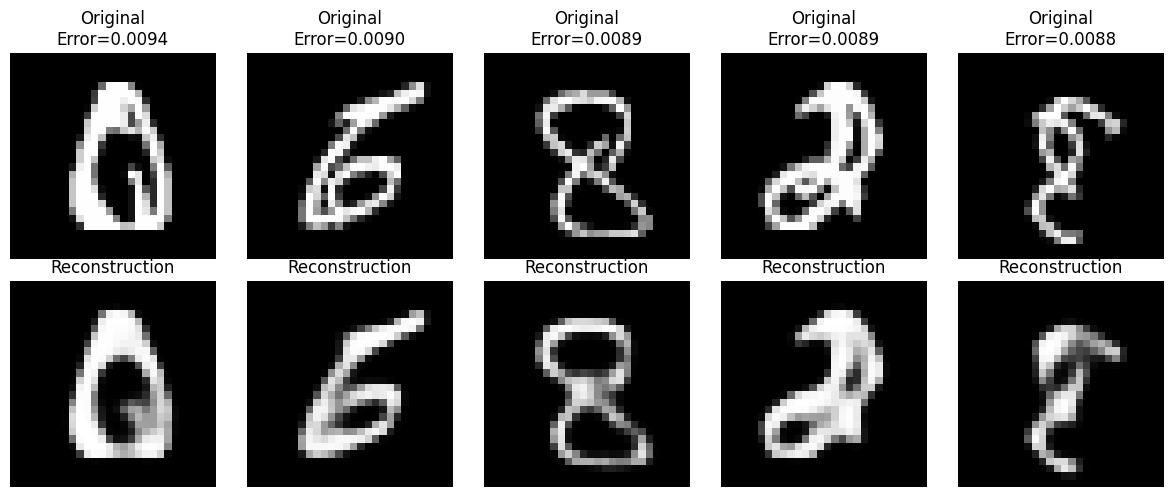

In [65]:
# ============================================
# CELL 56: DISPLAY TOP 5 HIGH-ERROR IMAGES
# ============================================

plt.figure(figsize=(12, 5))

for i, index in enumerate(top_5_indices):

    # Original
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test_cnn[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Original\nError={per_image_errors[index]:.4f}"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 5, i + 6)

    plt.imshow(
        x_test_cae_reconstructed[index].squeeze(),
        cmap="gray"
    )

    plt.title("Reconstruction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [66]:
# ============================================
# CELL 57: CONSOLIDATED RESULTS
# ============================================

print("=" * 95)
print("CONSOLIDATED MODEL RESULTS")
print("=" * 95)

print(
    f"{'Model':<25}"
    f"{'MSE':<12}"
    f"{'MAE':<12}"
    f"{'SSIM':<12}"
    f"{'Parameters':<15}"
)

print("-" * 95)

print(
    f"{'FC Autoencoder':<25}"
    f"{mse:<12.6f}"
    f"{mae:<12.6f}"
    f"{mean_ssim:<12.6f}"
    f"{fc_parameters:<15}"
)

print(
    f"{'Convolutional AE':<25}"
    f"{cae_mse:<12.6f}"
    f"{cae_mae:<12.6f}"
    f"{cae_mean_ssim:<12.6f}"
    f"{cae_parameters:<15}"
)

print(
    f"{'Denoising CAE':<25}"
    f"{denoise_mse:<12.6f}"
    f"{denoise_mae:<12.6f}"
    f"{denoise_ssim:<12.6f}"
    f"{denoising_cae.count_params():<15}"
)

print(
    f"{'VAE':<25}"
    f"{vae_mse:<12.6f}"
    f"{vae_mae:<12.6f}"
    f"{vae_ssim:<12.6f}"
    f"{vae.count_params():<15}"
)

print("=" * 95)

print("\nVAE Loss Components")
print("-" * 40)
print(f"Reconstruction Loss : {vae_reconstruction_loss:.6f}")
print(f"KL Loss             : {vae_kl_loss:.6f}")
print(f"Total Loss          : {vae_total_loss:.6f}")

CONSOLIDATED MODEL RESULTS
Model                    MSE         MAE         SSIM        Parameters     
-----------------------------------------------------------------------------------------------
FC Autoencoder           0.022668    0.059465    0.728743    211040         
Convolutional AE         0.002580    0.014898    0.974509    74497          
Denoising CAE            0.004471    0.020788    0.946785    74497          
VAE                      0.044742    0.103395    0.467958    485957         

VAE Loss Components
----------------------------------------
Reconstruction Loss : 150.143799
KL Loss             : 5.617647
Total Loss          : 155.761490


In [67]:
# ============================================
# CELL 58: FC AUTOENCODER BUILDER
# ============================================

def build_fc_autoencoder(latent_dim):

    model = keras.Sequential([

        layers.Input(shape=(784,)),

        # Encoder
        layers.Dense(128, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(latent_dim, activation="relu"),

        # Decoder
        layers.Dense(32, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(784, activation="sigmoid")

    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy"
    )

    return model

In [68]:
# ============================================
# CELL 59: LATENT DIMENSION STUDY
# ============================================

latent_dimensions = [2, 8, 16, 32]

latent_results = []

for dim in latent_dimensions:

    print(f"\nTraining latent dimension = {dim}")

    # Build model
    model = build_fc_autoencoder(dim)

    # Train model
    model.fit(
        x_train_flat,
        x_train_flat,
        validation_data=(
            x_test_flat,
            x_test_flat
        ),
        epochs=20,
        batch_size=128,
        shuffle=True,
        verbose=0
    )

    # Reconstruct test images
    reconstructed = model.predict(
        x_test_flat,
        verbose=0
    )

    # MSE
    model_mse = np.mean(
        (x_test_flat - reconstructed) ** 2
    )

    # SSIM
    model_ssim_values = []

    for i in range(len(x_test)):

        original = x_test[i]

        reconstruction = reconstructed[i].reshape(
            28, 28
        )

        score = ssim(
            original,
            reconstruction,
            data_range=1.0
        )

        model_ssim_values.append(score)

    model_ssim = np.mean(
        model_ssim_values
    )

    latent_results.append(
        [dim, model_mse, model_ssim]
    )

    print(
        f"MSE = {model_mse:.6f}, "
        f"SSIM = {model_ssim:.6f}"
    )


Training latent dimension = 2
MSE = 0.055202, SSIM = 0.317665

Training latent dimension = 8
MSE = 0.026644, SSIM = 0.687447

Training latent dimension = 16
MSE = 0.022865, SSIM = 0.730126

Training latent dimension = 32
MSE = 0.020106, SSIM = 0.758167


In [69]:
# ============================================
# CELL 60: LATENT DIMENSION RESULTS
# ============================================

print("=" * 45)
print("LATENT DIMENSION STUDY")
print("=" * 45)

print(
    f"{'Latent Dimension':<20}"
    f"{'MSE':<12}"
    f"{'SSIM':<12}"
)

print("-" * 45)

for result in latent_results:

    print(
        f"{result[0]:<20}"
        f"{result[1]:<12.6f}"
        f"{result[2]:<12.6f}"
    )

LATENT DIMENSION STUDY
Latent Dimension    MSE         SSIM        
---------------------------------------------
2                   0.055202    0.317665    
8                   0.026644    0.687447    
16                  0.022865    0.730126    
32                  0.020106    0.758167    


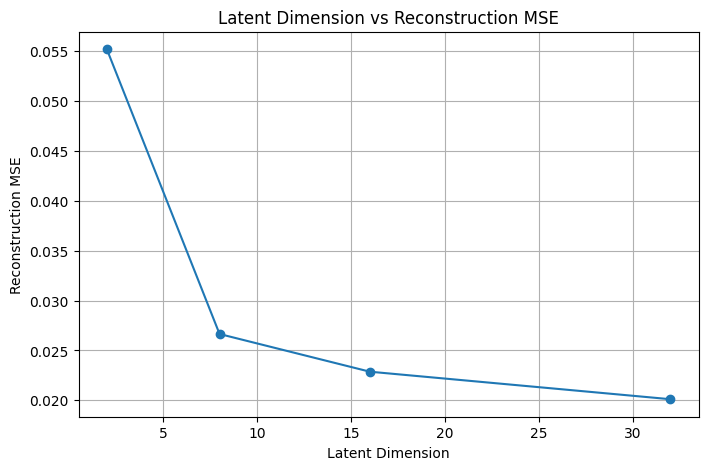

In [70]:
# ============================================
# CELL 61: LATENT DIMENSION vs MSE
# ============================================

dims = [
    result[0]
    for result in latent_results
]

mse_by_dim = [
    result[1]
    for result in latent_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    dims,
    mse_by_dim,
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction MSE")
plt.title("Latent Dimension vs Reconstruction MSE")
plt.grid(True)

plt.show()

# Discussion Questions

1. What is an autoencoder?

2. What is the purpose of the encoder?

3. What is the purpose of the decoder?

4. What is a latent representation?

5. Why is the latent representation usually smaller than the input?

6. What happens when the latent dimension is too small?

7. What happens when the latent dimension is increased?

8. Why can a convolutional autoencoder preserve spatial information more effectively?

9. Differentiate an autoencoder and a denoising autoencoder.

10. Why is the clean image used as the target in denoising?

11. What happens when the noise level is increased?

12. Why are MSE, MAE and SSIM useful for image reconstruction?

13. What is a Variational Autoencoder?

14. How does a VAE differ from a conventional autoencoder?

15. Why does a VAE learn a distribution instead of a single latent vector?

16. What is the reparameterization trick?

17. Why is ε sampled from a standard normal distribution?

18. What is the role of KL divergence in the VAE loss?

19. What is the prior distribution used in the VAE?

20. Why is a two-dimensional latent space useful for visualization?

21. What does latent-space interpolation demonstrate?

22. Why can a VAE generate new images?

23. Why might some VAE-generated images be unclear?

24. What is the difference between reconstruction and generation?

25. Why should test images remain unseen during training?


In [71]:
# ============================================
# ADDITIONAL EXERCISE 1:
# CAE LATENT DIMENSION COMPARISON
# ============================================

def build_cae_with_latent(latent_dim):

    encoder_input = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(encoder_input)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)

    # Flatten and Dense for actual latent dimension
    x = layers.Flatten()(x)
    latent_representation = layers.Dense(latent_dim, activation='relu')(x)

    # Decoder input will be the latent_dim
    decoder_input = keras.Input(shape=(latent_representation.shape[1],))

    # Decoder - reverse the flattening and add upsampling
    d = layers.Dense(7 * 7 * 64, activation='relu')(decoder_input) # Needs to match flattened size before latent layer
    d = layers.Reshape((7, 7, 64))(d)

    d = layers.UpSampling2D(2)(d)
    d = layers.Conv2D(32, 3, activation="relu", padding="same")(d)
    d = layers.UpSampling2D(2)(d)
    decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(d)

    encoder_model = keras.Model(encoder_input, latent_representation, name="cae_encoder")
    decoder_model = keras.Model(decoder_input, decoder_output, name="cae_decoder")

    # Combine to form the autoencoder
    autoencoder_output = decoder_model(encoder_model(encoder_input))
    autoencoder_model = keras.Model(encoder_input, autoencoder_output, name="cae_autoencoder")

    autoencoder_model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy"
    )

    return autoencoder_model

In [72]:
# ============================================
# TRAIN CAE FOR DIFFERENT LATENT DIMENSIONS
# ============================================

cae_latent_dims = [4, 8, 16, 32]
cae_latent_results = []

for dim in cae_latent_dims:

    print(f"Training CAE with latent dimension = {dim}")

    model = build_cae_with_latent(dim)

    model.fit(
        x_train_cnn,
        x_train_cnn,
        epochs=20,
        batch_size=128,
        validation_data=(x_test_cnn, x_test_cnn),
        verbose=0
    )

    reconstructed = model.predict(
        x_test_cnn,
        verbose=0
    )

    mse_value, mae_value, ssim_value = calculate_metrics(
        x_test_cnn,
        reconstructed
    )

    cae_latent_results.append(
        [dim, mse_value, ssim_value]
    )

    print(
        f"MSE: {mse_value:.6f}, "
        f"SSIM: {ssim_value:.6f}"
    )

Training CAE with latent dimension = 4
MSE: 0.035461, SSIM: 0.610713
Training CAE with latent dimension = 8
MSE: 0.022872, SSIM: 0.744092
Training CAE with latent dimension = 16
MSE: 0.012497, SSIM: 0.863173
Training CAE with latent dimension = 32
MSE: 0.008689, SSIM: 0.905526


In [73]:
# ============================================
# CAE LATENT DIMENSION RESULTS
# ============================================

print("Latent Dimension | MSE       | SSIM")
print("-" * 40)

for result in cae_latent_results:
    print(
        f"{result[0]:<16} | "
        f"{result[1]:.6f} | "
        f"{result[2]:.6f}"
    )

Latent Dimension | MSE       | SSIM
----------------------------------------
4                | 0.035461 | 0.610713
8                | 0.022872 | 0.744092
16               | 0.012497 | 0.863173
32               | 0.008689 | 0.905526


In [74]:
# ============================================
# ADDITIONAL EXERCISE 2:
# GAUSSIAN vs SALT-AND-PEPPER
# ============================================

# Generate test data with both noise types
gaussian_test = add_gaussian_noise(
    x_test_cnn,
    sigma=0.2
)

salt_pepper_test = add_salt_pepper_noise(
    x_test_cnn,
    p=0.10
)

# Denoise both using the same trained DAE
gaussian_denoised = denoising_cae.predict(
    gaussian_test,
    verbose=0
)

salt_pepper_denoised = denoising_cae.predict(
    salt_pepper_test,
    verbose=0
)

# Calculate metrics
gaussian_metrics = calculate_metrics(
    x_test_cnn,
    gaussian_denoised
)

sp_metrics = calculate_metrics(
    x_test_cnn,
    salt_pepper_denoised
)

print("Noise Type          MSE        MAE        SSIM")
print("-" * 55)

print(
    f"Gaussian            "
    f"{gaussian_metrics[0]:.6f}   "
    f"{gaussian_metrics[1]:.6f}   "
    f"{gaussian_metrics[2]:.6f}"
)

print(
    f"Salt-and-Pepper      "
    f"{sp_metrics[0]:.6f}   "
    f"{sp_metrics[1]:.6f}   "
    f"{sp_metrics[2]:.6f}"
)

Noise Type          MSE        MAE        SSIM
-------------------------------------------------------
Gaussian            0.004495   0.020874   0.946180
Salt-and-Pepper      0.007520   0.028352   0.871019


In [75]:
# ============================================
# ADDITIONAL EXERCISE 3:
# COMPARE TWO GAUSSIAN NOISE LEVELS
# ============================================

comparison_noise_levels = [0.1, 0.3]

for sigma in comparison_noise_levels:

    noisy = add_gaussian_noise(
        x_test_cnn,
        sigma=sigma
    )

    denoised = denoising_cae.predict(
        noisy,
        verbose=0
    )

    _, _, ssim_value = calculate_metrics(
        x_test_cnn,
        denoised
    )

    print(
        f"Noise level σ={sigma}: "
        f"SSIM = {ssim_value:.6f}"
    )

Noise level σ=0.1: SSIM = 0.960584
Noise level σ=0.3: SSIM = 0.882865


In [76]:
# ============================================
# ADDITIONAL EXERCISE 4:
# CAE WITH TRANSPOSED-CONVOLUTION DECODER
# ============================================

transpose_cae = keras.Sequential([

    # Encoder
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32, 3,
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64, 3,
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64, 3,
        activation="relu",
        padding="same"
    ),

    # Decoder using Conv2DTranspose
    layers.Conv2DTranspose(
        32,
        3,
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2DTranspose(
        16,
        3,
        strides=2,
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )
])

transpose_cae.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy"
)

transpose_cae.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,977 (308.50 KB)

 Trainable params: 78,977 (308.50 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# ============================================
# TRAIN TRANSPOSE-CONVOLUTION CAE
# ============================================

transpose_cae.fit(
    x_train_cnn,
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn, x_test_cnn),
    verbose=1
)

transpose_reconstructed = transpose_cae.predict(
    x_test_cnn,
    verbose=0
)

transpose_metrics = calculate_metrics(
    x_test_cnn,
    transpose_reconstructed
)

print("Transpose CAE")
print("MSE :", transpose_metrics[0])
print("MAE :", transpose_metrics[1])
print("SSIM:", transpose_metrics[2])

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.3737 - val_loss: 0.1318
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1043 - val_loss: 0.0866
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0841 - val_loss: 0.0788
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0786 - val_loss: 0.0755
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0755 - val_loss: 0.0728
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0735 - val_loss: 0.0713
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722 - val_loss: 0.0703
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0714 - val_loss: 0.0695
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0706 - val_loss: 0.0688
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0700 - val_loss: 0.0686
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0695 - val_loss: 0.0680
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0691 - val_l

In [78]:
# ============================================
# ADDITIONAL EXERCISE 5:
# VAE BUILDER FOR DIFFERENT LATENT DIMENSIONS
# ============================================

def build_vae(latent_dim):
    vae_instance = VAE(latent_dim=latent_dim)
    vae_instance.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
    return vae_instance

In [79]:
# ============================================
# TRAIN VAE WITH LATENT DIMENSION 8
# ============================================

vae8 = build_vae(8)

vae8.fit(
    x_train_cnn,
    epochs=20,
    batch_size=128,
    verbose=1
)

_, _, _, z8 = vae8.predict(
    x_test_cnn,
    verbose=0
)

print("Latent dimension 8 shape:", z8.shape)

# Evaluate VAE with latent dimension 8
vae8_reconstructed, _, _, _ = vae8.predict(x_test_cnn, verbose=0)
vae8_mse, vae8_mae, vae8_ssim = calculate_metrics(x_test_cnn, vae8_reconstructed)

print("\n===================================")
print("VAE (Latent Dim = 8) RECONSTRUCTION METRICS")
print("===================================")
print(f"VAE 8 Test MSE  : {vae8_mse:.6f}")
print(f"VAE 8 Test MAE  : {vae8_mae:.6f}")
print(f"VAE 8 Mean SSIM : {vae8_ssim:.6f}")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - kl_loss: 6.5615 - loss: 273.4296 - reconstruction_loss: 266.8681
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 5.5639 - loss: 199.6119 - reconstruction_loss: 194.0480
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 8.9770 - loss: 172.8486 - reconstruction_loss: 163.8717
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 10.8787 - loss: 157.6671 - reconstruction_loss: 146.7883
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 13.1989 - loss: 142.0757 - reconstruction_loss: 128.8769
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 15.0101 - loss: 128.1150 - reconstruction_loss: 113.1049
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 15.5143 - loss: 123.3597 - reconstruction_loss: 107.8455
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 15.7846 - loss: 120.4410 - reconstruction_loss: 104.6565
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_los

In [80]:
# ============================================
# ADDITIONAL EXERCISE 6:
# EFFECT OF KL-LOSS CONTRIBUTION (BETA-VAE)
# ============================================

beta = 2.0

class BetaVAE(VAE):
    def __init__(self, latent_dim=2, beta=1.0, **kwargs):
        super().__init__(latent_dim=latent_dim, **kwargs)
        self.beta = beta

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            reconstruction, mu, log_var, z = self(x)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(x, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var - tf.square(mu) - tf.exp(log_var),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        reconstruction, mu, log_var, z = self(x)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(x, reconstruction),
                axis=(1, 2),
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Instantiate and train the Beta-VAE
print(f"Training Beta-VAE with beta = {beta}")
beta_vae = BetaVAE(latent_dim=2, beta=beta)
beta_vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

beta_vae_history = beta_vae.fit(
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn,),
    shuffle=True
)

# Evaluate Beta-VAE
beta_vae_reconstructed, _, _, _ = beta_vae.predict(x_test_cnn, verbose=0)
beta_vae_mse, beta_vae_mae, beta_vae_ssim = calculate_metrics(x_test_cnn, beta_vae_reconstructed)

print("\n===================================")
print("BETA-VAE LOSS RESULTS")
print("===================================")
print(f"Reconstruction Loss : {beta_vae_history.history['reconstruction_loss'][-1]:.6f}")
print(f"KL Loss             : {beta_vae_history.history['kl_loss'][-1]:.6f}")
print(f"Total Loss          : {beta_vae_history.history['loss'][-1]:.6f}")

print("\n===================================")
print("BETA-VAE RECONSTRUCTION METRICS")
print("===================================")
print(f"Beta-VAE Test MSE  : {beta_vae_mse:.6f}")
print(f"Beta-VAE Test MAE  : {beta_vae_mae:.6f}")
print(f"Beta-VAE Mean SSIM : {beta_vae_ssim:.6f}")

Training Beta-VAE with beta = 2.0
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - kl_loss: 1.6998 - loss: 319.5203 - reconstruction_loss: 316.1207 - val_kl_loss: 1.5264 - val_loss: 205.5559 - val_reconstruction_loss: 202.5031
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - kl_loss: 1.9631 - loss: 205.6650 - reconstruction_loss: 201.7388 - val_kl_loss: 2.4268 - val_loss: 193.4289 - val_reconstruction_loss: 188.5752
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 1.9229 - loss: 196.8292 - reconstruction_loss: 192.9833 - val_kl_loss: 1.9987 - val_loss: 188.6531 - val_reconstruction_loss: 184.6557
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 1.8519 - loss: 193.5019 - reconstruction_loss: 189.7982 - val_kl_loss: 1.8753 - val_loss: 186.0633 - val_reconstruction_loss: 182.3127
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.3814 - loss: 188.6407 - reconstruction_loss: 183.8778 - val_kl_loss: 3.1932 - val_loss: 177.9468 - val_reconstructi

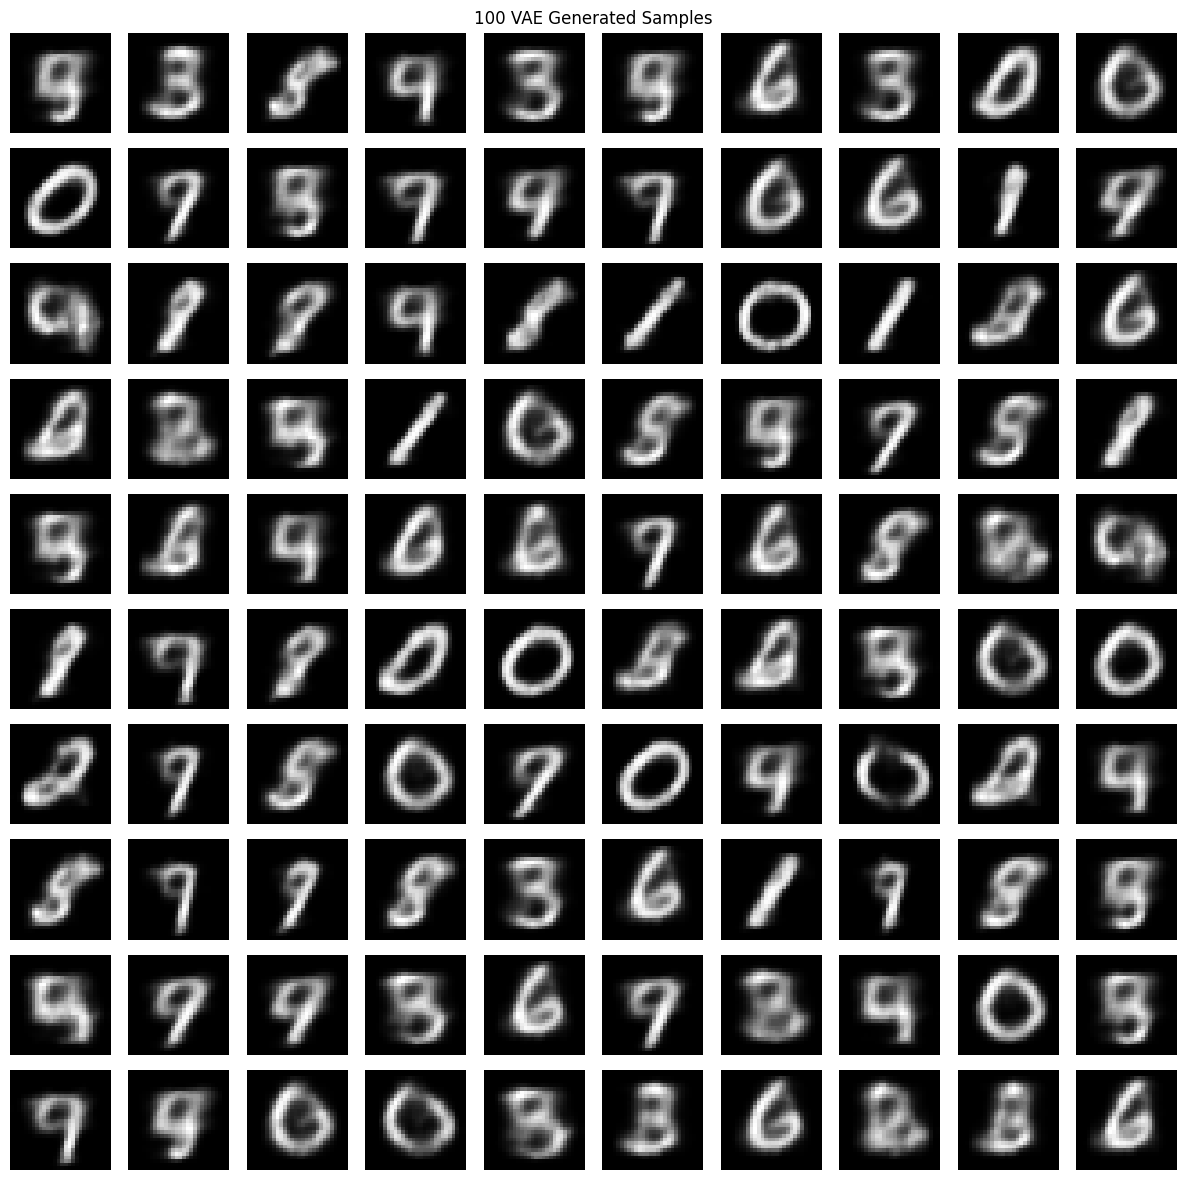

In [81]:
# ============================================
# ADDITIONAL EXERCISE 7:
# LARGER VAE SAMPLE GRID
# ============================================

num_samples = 100

# Sample from standard normal distribution
large_latent_samples = np.random.normal(
    size=(num_samples, vae.latent_dim)
).astype("float32")

# Generate images
large_generated_images = vae.decoder.predict(
    large_latent_samples,
    verbose=0
)

# Display 100 images
plt.figure(figsize=(12, 12))

for i in range(num_samples):

    plt.subplot(10, 10, i + 1)

    plt.imshow(
        large_generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("100 VAE Generated Samples")
plt.tight_layout()
plt.show()


In [82]:
# ============================================
# ADDITIONAL EXERCISE 8:
# INTERPOLATE BETWEEN TWO DIGIT REGIONS
# ============================================

# Choose two digit classes
digit_a = 0
digit_b = 1

# Find first test sample belonging to each digit
index_a = np.where(y_test == digit_a)[0][0]
index_b = np.where(y_test == digit_b)[0][0]

# Corresponding latent vectors
z_a = test_z[index_a]
z_b = test_z[index_b]

print("Digit A:", digit_a)
print("Digit B:", digit_b)
print("z_A:", z_a)
print("z_B:", z_b)

Digit A: 0
Digit B: 1
z_A: [-0.95579153  1.0494393 ]
z_B: [-0.89893526 -3.1440482 ]


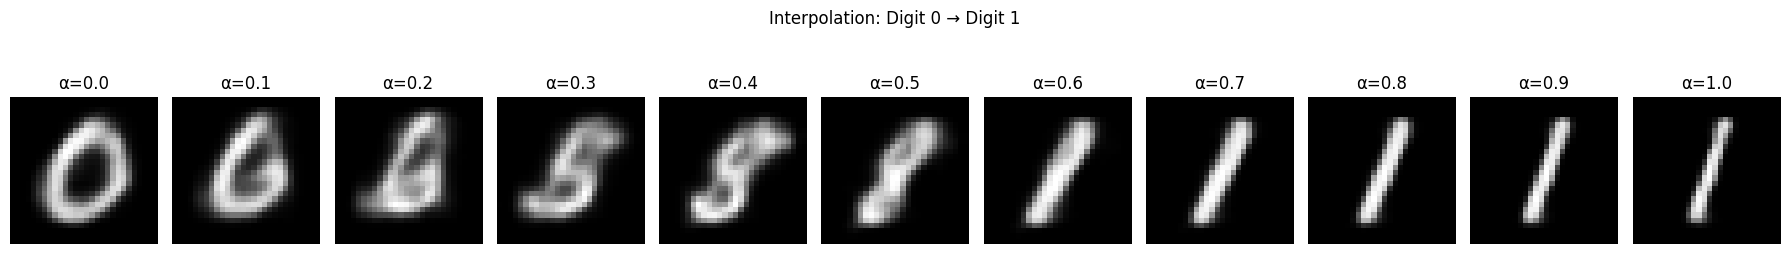

In [83]:
# ============================================
# INTERPOLATE BETWEEN THE TWO DIGIT REGIONS
# ============================================

alphas = np.arange(
    0.0,
    1.01,
    0.1
)

region_interpolations = []

for alpha in alphas:

    z_interp = (
        (1 - alpha) * z_a
        + alpha * z_b
    )

    region_interpolations.append(
        z_interp
    )

region_interpolations = np.array(
    region_interpolations
).astype("float32")

# Decode
region_images = vae.decoder.predict(
    region_interpolations,
    verbose=0
)

# Display
plt.figure(figsize=(18, 3))

for i in range(len(region_images)):

    plt.subplot(
        1,
        len(region_images),
        i + 1
    )

    plt.imshow(
        region_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"α={alphas[i]:.1f}")
    plt.axis("off")

plt.suptitle(
    f"Interpolation: Digit {digit_a} → Digit {digit_b}"
)

plt.tight_layout()
plt.show()

# Task
The notebook contains an error in Cell 40 where `vae_encoder` is not defined, leading to a `NameError`. Additionally, the existing VAE implementation is not encapsulated in a custom `keras.Model` subclass, which is crucial for proper loss tracking and validation data handling in modern TensorFlow/Keras. The CAE latent dimension study in Additional Exercise 1 also misrepresents the latent dimension.

The task is to fix these issues by:
1.  **Refactoring the VAE**: Redefine the VAE as a custom `keras.Model` subclass with a latent dimension of 2. This class will encapsulate the encoder and decoder, implement the reparameterization trick, and define `train_step` and `test_step` methods to correctly calculate reconstruction loss, KL divergence, and total loss, ensuring precise metric tracking and proper handling of validation data.
2.  **Correcting VAE Training and Latent Extraction**: Adjust the VAE training cell to use the new `VAE` class, ensuring the `fit` method correctly utilizes the custom `train_step` and `test_step`. Update Cell 40 to properly extract `mu`, `log_var`, and `z` from the refactored VAE's encoder.
3.  **Ensuring Downstream VAE Compatibility**: Verify and adjust all subsequent cells (Cells 41-52) that depend on the VAE's output for latent-space visualization, random image generation, latent-space interpolation, and VAE reconstruction metrics.
4.  **Fixing CAE Latent Dimension Study**: Modify the `build_cae_with_latent` function in Additional Exercise 1 (Cell s3g0C0uV0oSC) to correctly implement a true latent bottleneck using `Flatten` and `Dense` layers, and reverse this process in the decoder with `Dense` and `Reshape` layers.
5.  **Implementing Beta-VAE Experiment**: Implement a full β-VAE in Additional Exercise 6, defining and training a new VAE with `total_loss = reconstruction_loss + beta * KL_loss` where `beta = 2`. Evaluate its performance.
6.  **Verifying Notebook Integrity**: Conduct a comprehensive check to ensure all cells run without errors, variable names are consistent, tensor/image shapes match expectations, models train, plots generate, and all eight Additional Exercises are correctly implemented and functional.
7.  **Summarizing Changes**: Provide a summary of the fixes and confirm the notebook is ready to 'Run All'.

## Refactor VAE Implementation

### Subtask:
Redefine the VAE as a custom `keras.Model` subclass with a latent dimension of 2. This class will encapsulate the encoder and decoder, implement the reparameterization trick, and define `train_step` and `test_step` methods to correctly calculate reconstruction loss, KL divergence, and total loss, ensuring precise metric tracking and proper handling of validation data.
